In [3]:
file_path = "/dataset/Features_For_Traditional_ML_Techniques.csv"

In [4]:
# CELL 1: Import libraries and start Spark Session
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when, isnan
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import warnings
warnings.filterwarnings("ignore")

# Initialize SparkSession
spark = SparkSession.builder \
    .appName("FakeNews_Misinformation_Analysis") \
    .config("spark.memory.offHeap.enabled","true") \
    .config("spark.memory.offHeap.size","10g")\
    .config("spark.sql.session.timeZone", "UTC")\
    .getOrCreate()

# Suppress Spark CSV header warnings
spark.sparkContext.setLogLevel("ERROR")

print("Spark Session created successfully.")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/09 18:58:28 WARN Utils: Your hostname, Sandesh-Grangdan-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.69 instead (on interface en0)
26/03/09 18:58:28 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/09 18:58:28 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark Session created successfully.


In [5]:
# Added multiLine=True and escape='"' to properly parse the tweets
df = spark.read.csv(
    file_path, 
    header=True, 
    inferSchema=True, 
    multiLine=True, 
    escape='"'
)

# Drop the empty first column (_c0) that causes the CSV header warning
if "_c0" in df.columns:
    df = df.drop("_c0")

# Display the schema to verify data types
df.printSchema()

# Show the first 5 rows to verify columns align correctly now
df.show(5)

total_rows = df.count()
print(f"Total rows in dataset: {total_rows}")

root
 |-- majority_target: boolean (nullable = true)
 |-- statement: string (nullable = true)
 |-- BinaryNumTarget: double (nullable = true)
 |-- tweet: string (nullable = true)
 |-- followers_count: double (nullable = true)
 |-- friends_count: double (nullable = true)
 |-- favourites_count: double (nullable = true)
 |-- statuses_count: double (nullable = true)
 |-- listed_count: double (nullable = true)
 |-- following: double (nullable = true)
 |-- embeddings: string (nullable = true)
 |-- BotScore: double (nullable = true)
 |-- BotScoreBinary: double (nullable = true)
 |-- cred: double (nullable = true)
 |-- normalize_influence: double (nullable = true)
 |-- mentions: double (nullable = true)
 |-- quotes: double (nullable = true)
 |-- replies: double (nullable = true)
 |-- retweets: double (nullable = true)
 |-- favourites: double (nullable = true)
 |-- hashtags: double (nullable = true)
 |-- URLs: double (nullable = true)
 |-- unique_count: integer (nullable = true)
 |-- total_count

In [6]:
# CELL 3: Data Cleaning
# Select relevant features for our analysis
selected_cols = [
    'BinaryNumTarget', 'followers_count', 'friends_count', 
    'favourites_count', 'statuses_count', 'BotScore', 'cred', 
    'Word count', 'retweets', 'replies'
]

# We will cast to double, but now that the columns are aligned, 
# it shouldn't hit random text strings. 
# We use dropna() to remove any rows that genuinely have missing values.
clean_df = df.select([col(c).cast('double') for c in selected_cols]).dropna()

print(f"Rows after cleaning: {clean_df.count()}")

Rows after cleaning: 134198


In [7]:
# Export cleaned data for Tableau visualization
cleaned_export_path = "file:///Users/sandesh/Documents/bigdata/assignment/Tableau_Export_Data/cleaned_data"
clean_df.coalesce(1).write.mode('overwrite').csv(cleaned_export_path, header=True)
print(f"Cleaned data exported to {cleaned_export_path}")

Cleaned data exported to file:///Users/sandesh/Documents/bigdata/assignment/Tableau_Export_Data/cleaned_data


In [8]:
# CELL 4: K-Means Clustering
# Assemble features into a single vector column
cluster_features = ['followers_count', 'friends_count', 'statuses_count', 'retweets']
assembler_cluster = VectorAssembler(inputCols=cluster_features, outputCol="cluster_features")
cluster_data = assembler_cluster.transform(clean_df)

# Scale the data (important for K-Means)
scaler = StandardScaler(inputCol="cluster_features", outputCol="scaled_cluster_features")
scaler_model = scaler.fit(cluster_data)
scaled_cluster_data = scaler_model.transform(cluster_data)

# Train K-Means model (let's try to find 3 distinct user groups)
kmeans = KMeans(featuresCol="scaled_cluster_features", k=3, seed=42)
kmeans_model = kmeans.fit(scaled_cluster_data)

# Assign clusters to the data
clustered_df = kmeans_model.transform(scaled_cluster_data)
clustered_df.groupBy("prediction").count().show()

+----------+------+
|prediction| count|
+----------+------+
|         1|  5841|
|         2|   271|
|         0|128086|
+----------+------+



In [9]:
# Export clustered data for Tableau visualization
# Select only serializable columns (drop vector columns)
clustered_export_df = clustered_df.select(
    'BinaryNumTarget', 'followers_count', 'friends_count', 'favourites_count',
    'statuses_count', 'BotScore', 'cred', 'Word count', 'retweets', 'replies',
    col('prediction').alias('KMeans_Cluster')
)
clustered_export_path = "file:///Users/sandesh/Documents/bigdata/assignment/clustered_data"
clustered_export_df.coalesce(1).write.mode('overwrite').csv(clustered_export_path, header=True)
print(f"Clustered data exported to {clustered_export_path}")

Clustered data exported to file:///Users/sandesh/Documents/bigdata/assignment/clustered_data


In [10]:
# CELL 4B: K-Means Silhouette Score Analysis for optimal k
from pyspark.ml.evaluation import ClusteringEvaluator
import pandas as pd

# Test different k values to find the optimal one
silhouette_scores = []
k_values = range(2, 11)  # Test k from 2 to 10

for k in k_values:
    kmeans_test = KMeans(featuresCol="scaled_cluster_features", k=k, seed=42)
    model_test = kmeans_test.fit(scaled_cluster_data)
    predictions_test = model_test.transform(scaled_cluster_data)
    
    # Calculate silhouette score
    evaluator = ClusteringEvaluator(predictionCol="prediction", 
                                    featuresCol="scaled_cluster_features", 
                                    metricName="silhouette")
    silhouette = evaluator.evaluate(predictions_test)
    silhouette_scores.append((k, silhouette))
    print(f"k={k}, Silhouette Score={silhouette:.4f}")

# Find best k
best_k, best_score = max(silhouette_scores, key=lambda x: x[1])
print(f"\nBest k={best_k}, Silhouette Score={best_score:.4f}")

k=2, Silhouette Score=0.9999


k=3, Silhouette Score=0.9134


k=4, Silhouette Score=0.9982


k=5, Silhouette Score=0.9129
k=6, Silhouette Score=0.9184


k=7, Silhouette Score=0.9177


k=8, Silhouette Score=0.7755


k=9, Silhouette Score=0.8375


k=10, Silhouette Score=0.7677

Best k=2, Silhouette Score=0.9999


In [11]:
# CELL 4C: K-Means Cluster Profile (Mean normalized feature values)
from pyspark.sql.functions import mean, stddev

# Get cluster assignments
clustered_for_profile = clustered_df.select(
    'followers_count', 'friends_count', 'statuses_count', 'retweets', 'prediction'
)

# Calculate mean values for each cluster
cluster_profile = clustered_for_profile.groupBy("prediction").agg(
    mean("followers_count").alias("Avg_Followers"),
    mean("friends_count").alias("Avg_Friends"),
    mean("statuses_count").alias("Avg_Statuses"),
    mean("retweets").alias("Avg_Retweets")
)

# Rename prediction column to Cluster
cluster_profile_renamed = cluster_profile.withColumnRenamed("prediction", "Cluster")

print("K-Means Cluster Profile (Mean Feature Values):")
cluster_profile_renamed.show()

K-Means Cluster Profile (Mean Feature Values):
+-------+------------------+------------------+------------------+------------------+
|Cluster|     Avg_Followers|       Avg_Friends|      Avg_Statuses|      Avg_Retweets|
+-------+------------------+------------------+------------------+------------------+
|      1|  55905.5439137134| 7590.164869029276|  292668.391200137|5.6245505906522855|
|      2|1179599.8634686347|110846.10332103321|181851.62361623617| 1118.261992619926|
|      0| 6786.793146791999|1403.1537716846494|22096.442483956092| 4.370368346267352|
+-------+------------------+------------------+------------------+------------------+



In [12]:
# CELL 5: Random Forest Classification
# Prepare data for classification
clf_features = ['followers_count', 'BotScore', 'cred', 'Word count', 'retweets']
assembler_clf = VectorAssembler(inputCols=clf_features, outputCol="features")
clf_data = assembler_clf.transform(clustered_df)

# Split data into training and testing sets (80/20)
train_data, test_data = clf_data.randomSplit([0.8, 0.2], seed=42)

# Initialize and train the Random Forest Classifier
# FIX: Added predictionCol="rf_prediction" to avoid the column name clash
rf = RandomForestClassifier(
    labelCol="BinaryNumTarget", 
    featuresCol="features", 
    numTrees=20, 
    predictionCol="rf_prediction"
)
rf_model = rf.fit(train_data)

# Make predictions on the test set
predictions = rf_model.transform(test_data)

# Evaluate the model
# FIX: Updated predictionCol here as well to match the model output
evaluator = MulticlassClassificationEvaluator(
    labelCol="BinaryNumTarget", 
    predictionCol="rf_prediction", 
    metricName="accuracy"
)
accuracy = evaluator.evaluate(predictions)
print(f"Random Forest Classification Accuracy: {accuracy * 100:.2f}%")

Random Forest Classification Accuracy: 56.72%


Comprehensive visualizations saved to: comprehensive_visualizations.png


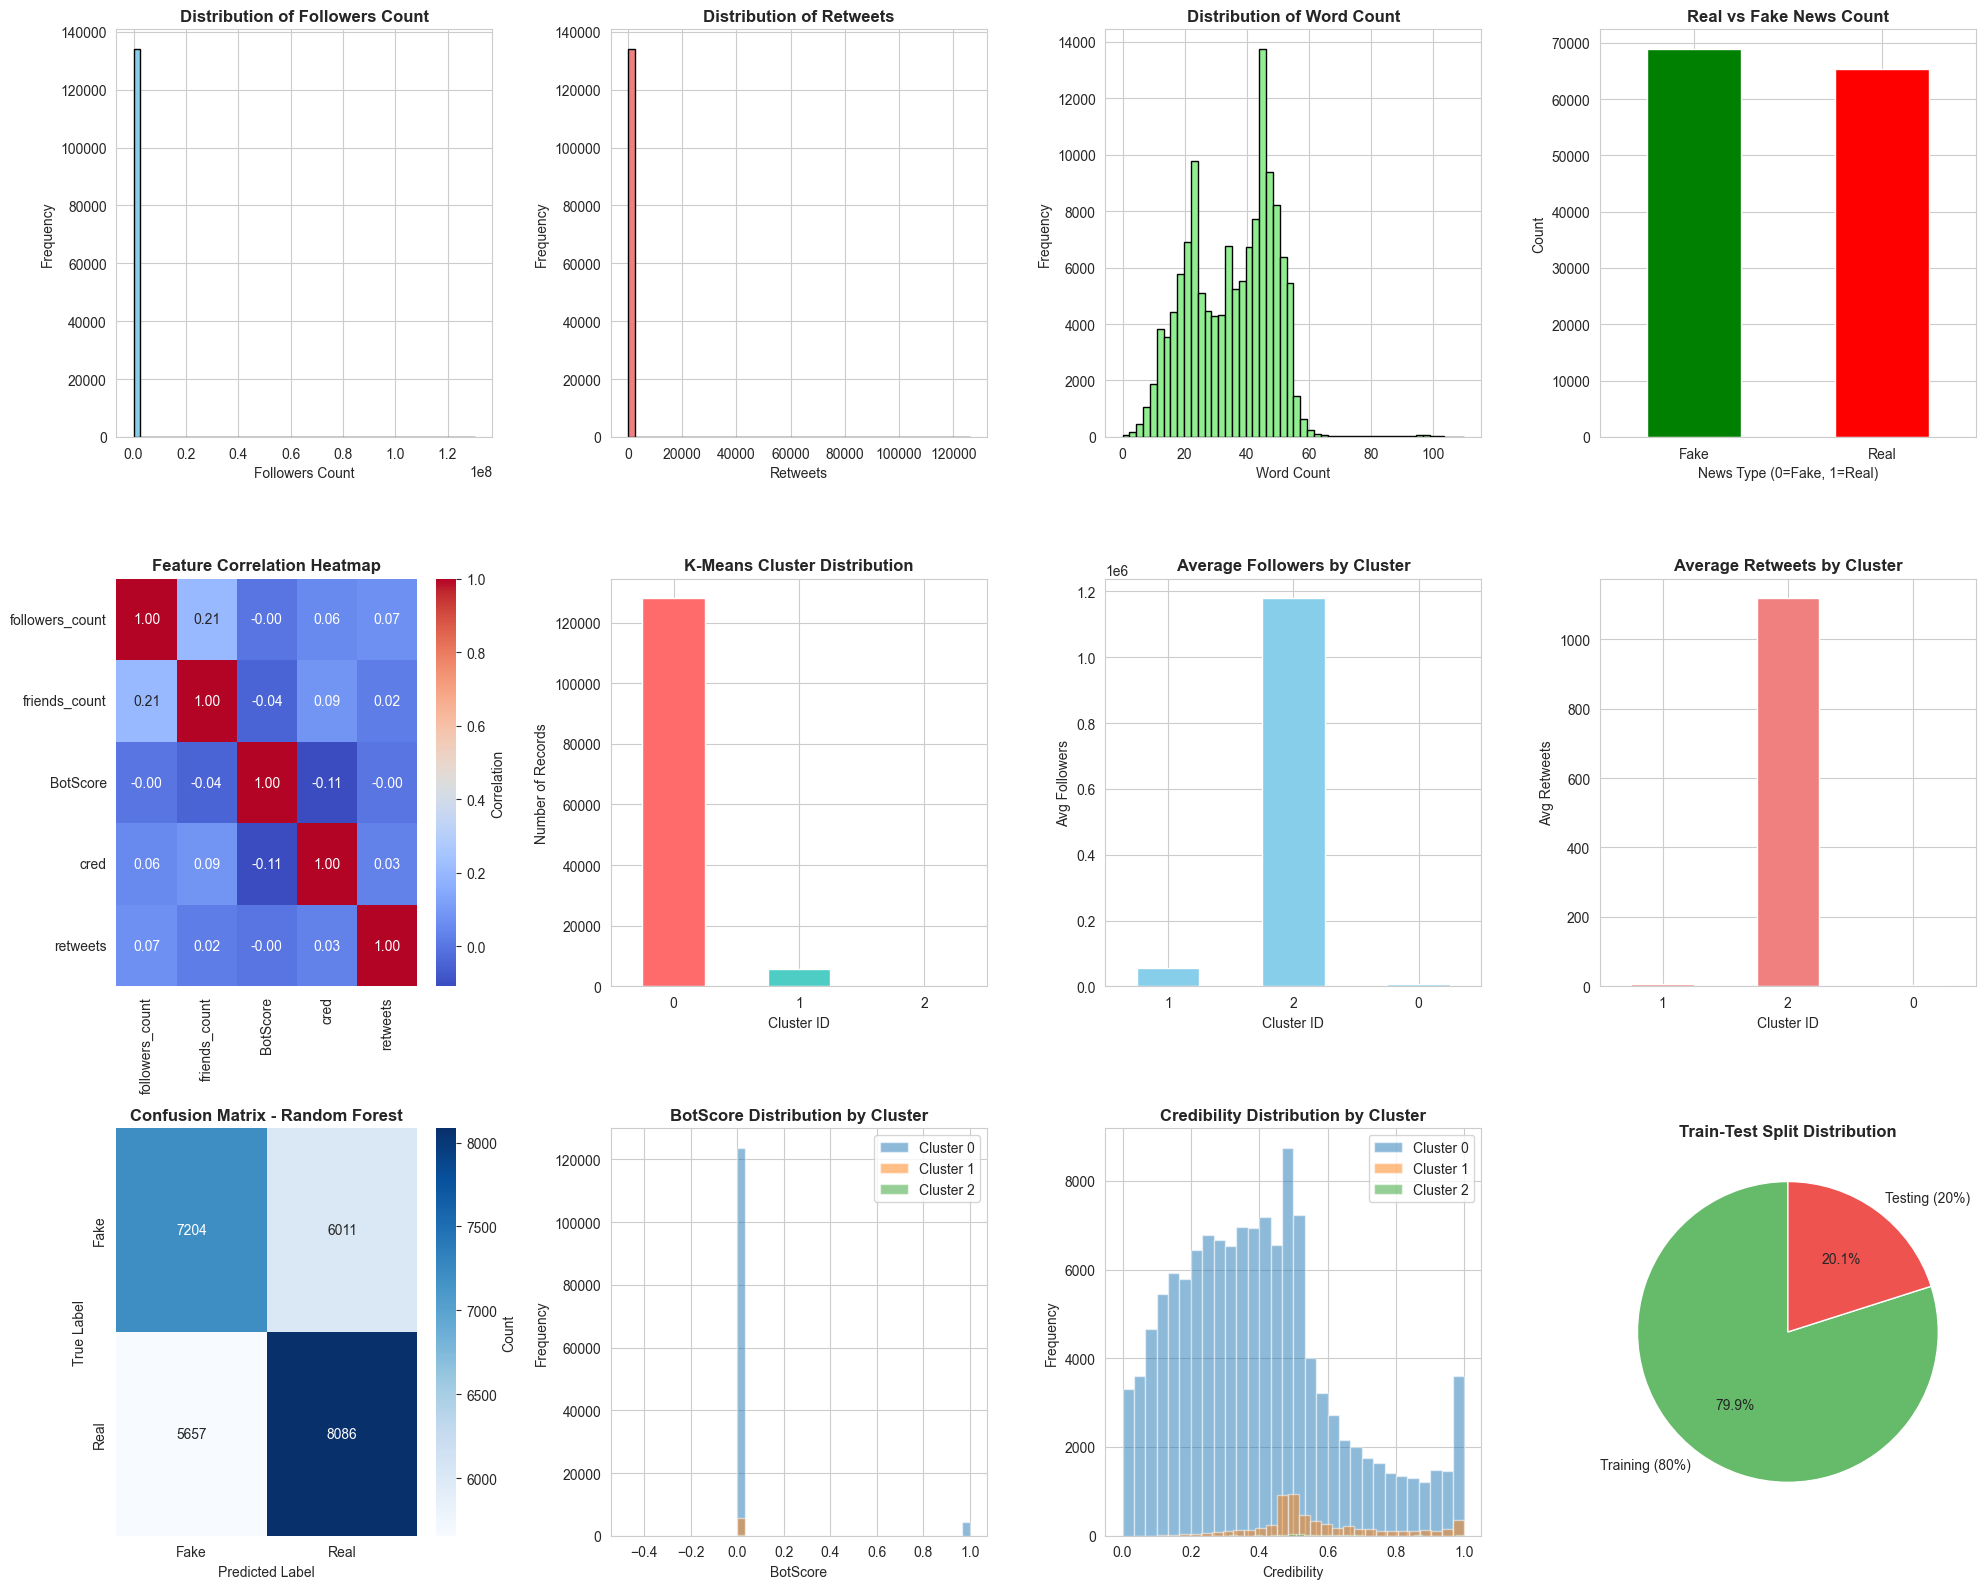


RANDOM FOREST CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Fake       0.56      0.55      0.55     13215
        Real       0.57      0.59      0.58     13743

    accuracy                           0.57     26958
   macro avg       0.57      0.57      0.57     26958
weighted avg       0.57      0.57      0.57     26958


Confusion Matrix Details:
True Negatives (TN): 7204
False Positives (FP): 6011
False Negatives (FN): 5657
True Positives (TP): 8086

Accuracy: 0.5672
Precision: 0.5736
Recall: 0.5884
F1-Score: 0.5809


In [14]:
# CELL 7: Comprehensive Visualizations using Matplotlib and Seaborn
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from pyspark.sql.functions import col

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 12)

# Convert Spark DataFrames to Pandas for visualization
clean_df_pandas = clean_df.toPandas()
predictions_pandas = predictions.toPandas()
cluster_profile_pandas = cluster_profile_renamed.toPandas()

# Create a figure with multiple subplots
fig = plt.figure(figsize=(20, 16))

# ============= 1. Data Distribution - Followers Count =============
ax1 = plt.subplot(3, 4, 1)
clean_df_pandas['followers_count'].hist(bins=50, ax=ax1, color='skyblue', edgecolor='black')
ax1.set_title('Distribution of Followers Count', fontsize=12, fontweight='bold')
ax1.set_xlabel('Followers Count')
ax1.set_ylabel('Frequency')

# ============= 2. Data Distribution - Retweets =============
ax2 = plt.subplot(3, 4, 2)
clean_df_pandas['retweets'].hist(bins=50, ax=ax2, color='lightcoral', edgecolor='black')
ax2.set_title('Distribution of Retweets', fontsize=12, fontweight='bold')
ax2.set_xlabel('Retweets')
ax2.set_ylabel('Frequency')

# ============= 3. Data Distribution - Word Count =============
ax3 = plt.subplot(3, 4, 3)
clean_df_pandas['Word count'].hist(bins=50, ax=ax3, color='lightgreen', edgecolor='black')
ax3.set_title('Distribution of Word Count', fontsize=12, fontweight='bold')
ax3.set_xlabel('Word Count')
ax3.set_ylabel('Frequency')

# ============= 4. Real vs Fake News Distribution =============
ax4 = plt.subplot(3, 4, 4)
clean_df_pandas['BinaryNumTarget'].value_counts().plot(kind='bar', ax=ax4, color=['green', 'red'])
ax4.set_title('Real vs Fake News Count', fontsize=12, fontweight='bold')
ax4.set_xlabel('News Type (0=Fake, 1=Real)')
ax4.set_ylabel('Count')
ax4.set_xticklabels(['Fake', 'Real'], rotation=0)

# ============= 5. Feature Correlation Heatmap =============
ax5 = plt.subplot(3, 4, 5)
selected_features = ['followers_count', 'friends_count', 'BotScore', 'cred', 'retweets']
correlation_matrix = clean_df_pandas[selected_features].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=ax5, cbar_kws={'label': 'Correlation'})
ax5.set_title('Feature Correlation Heatmap', fontsize=12, fontweight='bold')

# ============= 6. K-Means Cluster Distribution =============
ax6 = plt.subplot(3, 4, 6)
clustered_df_pandas = clustered_df.select('prediction').toPandas()
clustered_df_pandas['prediction'].value_counts().sort_index().plot(kind='bar', ax=ax6, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax6.set_title('K-Means Cluster Distribution', fontsize=12, fontweight='bold')
ax6.set_xlabel('Cluster ID')
ax6.set_ylabel('Number of Records')
ax6.set_xticklabels(ax6.get_xticklabels(), rotation=0)

# ============= 7. Cluster Profile - Average Followers =============
ax7 = plt.subplot(3, 4, 7)
cluster_profile_pandas.plot(x='Cluster', y='Avg_Followers', kind='bar', ax=ax7, legend=False, color='skyblue')
ax7.set_title('Average Followers by Cluster', fontsize=12, fontweight='bold')
ax7.set_xlabel('Cluster ID')
ax7.set_ylabel('Avg Followers')
ax7.set_xticklabels(ax7.get_xticklabels(), rotation=0)

# ============= 8. Cluster Profile - Average Retweets =============
ax8 = plt.subplot(3, 4, 8)
cluster_profile_pandas.plot(x='Cluster', y='Avg_Retweets', kind='bar', ax=ax8, legend=False, color='lightcoral')
ax8.set_title('Average Retweets by Cluster', fontsize=12, fontweight='bold')
ax8.set_xlabel('Cluster ID')
ax8.set_ylabel('Avg Retweets')
ax8.set_xticklabels(ax8.get_xticklabels(), rotation=0)

# ============= 9. Confusion Matrix - RF Classifier =============
ax9 = plt.subplot(3, 4, 9)
# Extract actual and predicted values
y_true = predictions_pandas['BinaryNumTarget'].values
y_pred = predictions_pandas['rf_prediction'].values
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax9, cbar_kws={'label': 'Count'})
ax9.set_title('Confusion Matrix - Random Forest', fontsize=12, fontweight='bold')
ax9.set_ylabel('True Label')
ax9.set_xlabel('Predicted Label')
ax9.set_xticklabels(['Fake', 'Real'])
ax9.set_yticklabels(['Fake', 'Real'])

# ============= 10. Bot Score Distribution by Cluster =============
ax10 = plt.subplot(3, 4, 10)
clustered_df_with_bs = clustered_df.select('BotScore', 'prediction').toPandas()
for cluster in clustered_df_with_bs['prediction'].unique():
    data = clustered_df_with_bs[clustered_df_with_bs['prediction'] == cluster]['BotScore']
    ax10.hist(data, bins=30, alpha=0.5, label=f'Cluster {int(cluster)}')
ax10.set_title('BotScore Distribution by Cluster', fontsize=12, fontweight='bold')
ax10.set_xlabel('BotScore')
ax10.set_ylabel('Frequency')
ax10.legend()

# ============= 11. Credibility Distribution by Cluster =============
ax11 = plt.subplot(3, 4, 11)
clustered_df_with_cred = clustered_df.select('cred', 'prediction').toPandas()
for cluster in clustered_df_with_cred['prediction'].unique():
    data = clustered_df_with_cred[clustered_df_with_cred['prediction'] == cluster]['cred']
    ax11.hist(data, bins=30, alpha=0.5, label=f'Cluster {int(cluster)}')
ax11.set_title('Credibility Distribution by Cluster', fontsize=12, fontweight='bold')
ax11.set_xlabel('Credibility')
ax11.set_ylabel('Frequency')
ax11.legend()

# ============= 12. Training vs Testing Data Distribution =============
ax12 = plt.subplot(3, 4, 12)
train_test_sizes = ['Training (80%)', 'Testing (20%)']
sizes = [len(train_data.toPandas()), len(test_data.toPandas())]
colors = ['#66BB6A', '#EF5350']
ax12.pie(sizes, labels=train_test_sizes, autopct='%1.1f%%', colors=colors, startangle=90)
ax12.set_title('Train-Test Split Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('/Users/sandesh/Documents/bigdata/assignment/comprehensive_visualizations.png', dpi=300, bbox_inches='tight')
print("Comprehensive visualizations saved to: comprehensive_visualizations.png")
plt.show()

# Print Classification Report
print("\n" + "="*60)
print("RANDOM FOREST CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred, target_names=['Fake', 'Real']))

# Print Confusion Matrix Details
print("\nConfusion Matrix Details:")
print(f"True Negatives (TN): {cm[0,0]}")
print(f"False Positives (FP): {cm[0,1]}")
print(f"False Negatives (FN): {cm[1,0]}")
print(f"True Positives (TP): {cm[1,1]}")

# Calculate additional metrics
accuracy = (cm[0,0] + cm[1,1]) / cm.sum()
precision = cm[1,1] / (cm[1,1] + cm[0,1])
recall = cm[1,1] / (cm[1,1] + cm[1,0])
f1 = 2 * (precision * recall) / (precision + recall)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

In [15]:
# CELL 8: Export All Visualizations as CSV for Tableau
import pandas as pd
import os
from sklearn.metrics import confusion_matrix, classification_report

# Base export path (using relative path)
export_base = 'tableau_export_data'

# Create the export directory if it doesn't exist
os.makedirs(export_base, exist_ok=True)

# Convert key dataframes to Pandas
clean_df_pandas = clean_df.toPandas()
predictions_pandas = predictions.toPandas()
cluster_profile_pandas = cluster_profile_renamed.toPandas()
clustered_df_pandas = clustered_df.select('prediction').toPandas()

print("Exporting visualization data for Tableau...\n")

# ============= 1. Distribution of Followers Count =============
# Create bins and extract numeric boundaries for better visualization in Tableau
followers_binned = pd.cut(clean_df_pandas['followers_count'], bins=50)
followers_counts = followers_binned.value_counts().sort_index()

# Extract bin boundaries from the index
bin_starts = [float(interval.left) for interval in followers_counts.index]
bin_ends = [float(interval.right) for interval in followers_counts.index]
bin_midpoints = [(float(interval.left) + float(interval.right)) / 2 for interval in followers_counts.index]

# Create export dataframe
export_df_followers = pd.DataFrame({
    'Followers_Midpoint': bin_midpoints,
    'Bin_Start': bin_starts,
    'Bin_End': bin_ends,
    'Frequency': followers_counts.values
})
export_df_followers.to_csv(f'{export_base}/viz_01_followers_distribution.csv', index=False)
print("✓ Exported: viz_01_followers_distribution.csv")

# ============= 2. Distribution of Retweets =============
retweets_binned = pd.cut(clean_df_pandas['retweets'], bins=50)
retweets_counts = retweets_binned.value_counts().sort_index()

# Extract bin boundaries from the index
bin_starts = [float(interval.left) for interval in retweets_counts.index]
bin_ends = [float(interval.right) for interval in retweets_counts.index]
bin_midpoints = [(float(interval.left) + float(interval.right)) / 2 for interval in retweets_counts.index]

# Create export dataframe
export_df_retweets = pd.DataFrame({
    'Retweets_Midpoint': bin_midpoints,
    'Bin_Start': bin_starts,
    'Bin_End': bin_ends,
    'Frequency': retweets_counts.values
})
export_df_retweets.to_csv(f'{export_base}/viz_02_retweets_distribution.csv', index=False)
print("✓ Exported: viz_02_retweets_distribution.csv")

# ============= 3. Distribution of Word Count =============
wordcount_binned = pd.cut(clean_df_pandas['Word count'], bins=50)
wordcount_counts = wordcount_binned.value_counts().sort_index()

# Extract bin boundaries from the index
bin_starts = [float(interval.left) for interval in wordcount_counts.index]
bin_ends = [float(interval.right) for interval in wordcount_counts.index]
bin_midpoints = [(float(interval.left) + float(interval.right)) / 2 for interval in wordcount_counts.index]

# Create export dataframe
export_df_wordcount = pd.DataFrame({
    'WordCount_Midpoint': bin_midpoints,
    'Bin_Start': bin_starts,
    'Bin_End': bin_ends,
    'Frequency': wordcount_counts.values
})
export_df_wordcount.to_csv(f'{export_base}/viz_03_wordcount_distribution.csv', index=False)
print("✓ Exported: viz_03_wordcount_distribution.csv")

# ============= 4. Real vs Fake News Distribution =============
news_dist = pd.DataFrame({
    'News_Type': ['Fake (0)', 'Real (1)'],
    'Count': clean_df_pandas['BinaryNumTarget'].value_counts().sort_index().values
})
news_dist.to_csv(f'{export_base}/viz_04_real_vs_fake_news.csv', index=False)
print("✓ Exported: viz_04_real_vs_fake_news.csv")

# ============= 5. Feature Correlation Heatmap =============
selected_features = ['followers_count', 'friends_count', 'BotScore', 'cred', 'retweets']
correlation_matrix = clean_df_pandas[selected_features].corr()
correlation_matrix.to_csv(f'{export_base}/viz_05_feature_correlation.csv')
print("✓ Exported: viz_05_feature_correlation.csv")

# ============= 6. K-Means Cluster Distribution =============
cluster_dist = clustered_df_pandas['prediction'].value_counts().sort_index().reset_index()
cluster_dist.columns = ['Cluster_ID', 'Count']
cluster_dist.to_csv(f'{export_base}/viz_06_kmeans_cluster_distribution.csv', index=False)
print("✓ Exported: viz_06_kmeans_cluster_distribution.csv")

# ============= 7 & 8. Cluster Profile =============
cluster_profile_pandas.to_csv(f'{export_base}/viz_07_08_cluster_profile.csv', index=False)
print("✓ Exported: viz_07_08_cluster_profile.csv")

# ============= 9. Confusion Matrix =============
y_true = predictions_pandas['BinaryNumTarget'].values
y_pred = predictions_pandas['rf_prediction'].values
cm = confusion_matrix(y_true, y_pred)
confusion_matrix_df = pd.DataFrame({
    'Predicted_Fake': [cm[0,0], cm[1,0]],
    'Predicted_Real': [cm[0,1], cm[1,1]]
}, index=['Actual_Fake', 'Actual_Real'])
confusion_matrix_df.to_csv(f'{export_base}/viz_09_confusion_matrix.csv')
print("✓ Exported: viz_09_confusion_matrix.csv")

# ============= 10. BotScore Distribution by Cluster =============
clustered_df_with_bs = clustered_df.select('BotScore', 'prediction').toPandas()
botscore_data = []
for cluster in sorted(clustered_df_with_bs['prediction'].unique()):
    data = clustered_df_with_bs[clustered_df_with_bs['prediction'] == cluster]['BotScore']
    for value in data:
        botscore_data.append({'Cluster': int(cluster), 'BotScore': value})
botscore_dist_df = pd.DataFrame(botscore_data)
botscore_dist_df.to_csv(f'{export_base}/viz_10_botscore_by_cluster.csv', index=False)
print("✓ Exported: viz_10_botscore_by_cluster.csv")

# ============= 11. Credibility Distribution by Cluster =============
clustered_df_with_cred = clustered_df.select('cred', 'prediction').toPandas()
cred_data = []
for cluster in sorted(clustered_df_with_cred['prediction'].unique()):
    data = clustered_df_with_cred[clustered_df_with_cred['prediction'] == cluster]['cred']
    for value in data:
        cred_data.append({'Cluster': int(cluster), 'Credibility': value})
cred_dist_df = pd.DataFrame(cred_data)
cred_dist_df.to_csv(f'{export_base}/viz_11_credibility_by_cluster.csv', index=False)
print("✓ Exported: viz_11_credibility_by_cluster.csv")

# ============= 12. Training vs Testing Split =============
train_size = len(train_data.toPandas())
test_size = len(test_data.toPandas())
split_dist = pd.DataFrame({
    'Data_Set': ['Training (80%)', 'Testing (20%)'],
    'Count': [train_size, test_size],
    'Percentage': [80.0, 20.0]
})
split_dist.to_csv(f'{export_base}/viz_12_train_test_split.csv', index=False)
print("✓ Exported: viz_12_train_test_split.csv")

# ============= Classification Metrics =============
accuracy = (cm[0,0] + cm[1,1]) / cm.sum()
precision = cm[1,1] / (cm[1,1] + cm[0,1]) if (cm[1,1] + cm[0,1]) > 0 else 0
recall = cm[1,1] / (cm[1,1] + cm[1,0]) if (cm[1,1] + cm[1,0]) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [accuracy, precision, recall, f1]
})
metrics_df.to_csv(f'{export_base}/model_performance_metrics.csv', index=False)
print("✓ Exported: model_performance_metrics.csv")

print("\n" + "="*60)
print("ALL VISUALIZATION DATA EXPORTED SUCCESSFULLY!")
print("="*60)
print(f"\nLocation: {export_base}/")
print("\nFiles exported:")
print("  1. viz_01_followers_distribution.csv")
print("  2. viz_02_retweets_distribution.csv")
print("  3. viz_03_wordcount_distribution.csv")
print("  4. viz_04_real_vs_fake_news.csv")
print("  5. viz_05_feature_correlation.csv")
print("  6. viz_06_kmeans_cluster_distribution.csv")
print("  7. viz_07_08_cluster_profile.csv")
print("  8. viz_09_confusion_matrix.csv")
print("  9. viz_10_botscore_by_cluster.csv")
print("  10. viz_11_credibility_by_cluster.csv")
print("  11. viz_12_train_test_split.csv")
print("  12. model_performance_metrics.csv")

Exporting visualization data for Tableau...

✓ Exported: viz_01_followers_distribution.csv
✓ Exported: viz_02_retweets_distribution.csv
✓ Exported: viz_03_wordcount_distribution.csv
✓ Exported: viz_04_real_vs_fake_news.csv
✓ Exported: viz_05_feature_correlation.csv
✓ Exported: viz_06_kmeans_cluster_distribution.csv
✓ Exported: viz_07_08_cluster_profile.csv
✓ Exported: viz_09_confusion_matrix.csv
✓ Exported: viz_10_botscore_by_cluster.csv
✓ Exported: viz_11_credibility_by_cluster.csv


✓ Exported: viz_12_train_test_split.csv
✓ Exported: model_performance_metrics.csv

ALL VISUALIZATION DATA EXPORTED SUCCESSFULLY!

Location: tableau_export_data/

Files exported:
  1. viz_01_followers_distribution.csv
  2. viz_02_retweets_distribution.csv
  3. viz_03_wordcount_distribution.csv
  4. viz_04_real_vs_fake_news.csv
  5. viz_05_feature_correlation.csv
  6. viz_06_kmeans_cluster_distribution.csv
  7. viz_07_08_cluster_profile.csv
  8. viz_09_confusion_matrix.csv
  9. viz_10_botscore_by_cluster.csv
  10. viz_11_credibility_by_cluster.csv
  11. viz_12_train_test_split.csv
  12. model_performance_metrics.csv
